In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :retina
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "QzpcVXNlcnNcTmlrb2xhalxHaXRcZ3JhcGgtZXF1aWxpYnJpdW0tcmFkaWF0aXZlLXRyYW5zZmVyXGV4YW1wbGVz"
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
using RayTraceHeatTransfer, GeometryBasics, StaticArrays

Nlarge   = 1001                                                                     # cells in each direction
vertices = SVector(Point2(0.0, 0.0), Point2(1000.0, 0.0), Point2(1000.0, 1.0), Point2(0.0, 1.0))   # 1000 m long, 1 m between the long walls
face     = PolyVolume2D{Float64}(vertices, SVector(true, true, true, true), 1, 100.0, 0.0)   # κ = 100 m⁻¹, no scattering
face.T_in_w  = [1000.0, 0.0, 0.0, 0.0]                                              # hot bottom wall, three cold walls
face.epsilon = [1.0, 1.0, 1.0, 1.0]                                                 # black walls
face.T_in_g  = -1.0                                                                 # gas temperature unknown
face.q_in_g  = 0.0                                                                  # radiative equilibrium: no heat source in the gas

t_build = @elapsed big = RayTracingDomain2D([face], [(Nlarge, Nlarge)]; verbose = false)   # 1001 × 1001 cells

8.0243685

In [3]:
sampler  = :random                                                      # pseudorandom; :sobol is the default
emitters = length(big.surface_mapping) + length(big.volume_mapping)     # 4 × 1001 wall elements and 1001² cells
rays     = emitters * 2^10                                              # 2¹⁰ rays per emitter, about 10⁹ in total

t_trace  = @elapsed big(rays; method = :exchange, sampler = sampler, verbose = false)   # the exchange factors
t_smooth = @elapsed stats = smooth!(big; verbose = false)                              # reciprocity and conservation
stats                                                                                  # which projection ran, and how many iterations

(converged = Bool[1], delta_raw = [19.77197062561992], delta_smooth = [1.2797354741927698e-14], k_dykstra = [0], k_ap = [75], k_pcg_tot = [0], k_pcg_max = [0])

In [4]:
# Centreline source function S = (T/T_hot)⁴ of a solved mesh, from the hot wall upwards
function centreline_S(m, N)
    T = reshape([cell.T_g for cell in m.fine_mesh[1]], N, N)    # temperatures as T[column, row], rows from the hot wall
    return (T[div(N + 1, 2), :] ./ 1000.0) .^ 4                  # the middle column; T_hot = 1000 K
end

t_solve_raw = @elapsed solveEquilibrium!(big, big.F_raw; verbose = false)      # the raw factors, for comparison only
S_raw       = centreline_S(big, Nlarge)                                        # their centreline
t_solve     = @elapsed solveEquilibrium!(big, big.F_smooth; verbose = false)   # the smoothed factors
S_smooth    = centreline_S(big, Nlarge);                                       # their centreline

rms deviation from diffusion: raw = 0.0314, smoothed = 0.000773, reduction = 97.5 %
time: build 8.0 s, trace 29.2 s, smooth 9.7 s, solve 70.5 s (raw solve 63.8 s), on 28 threads


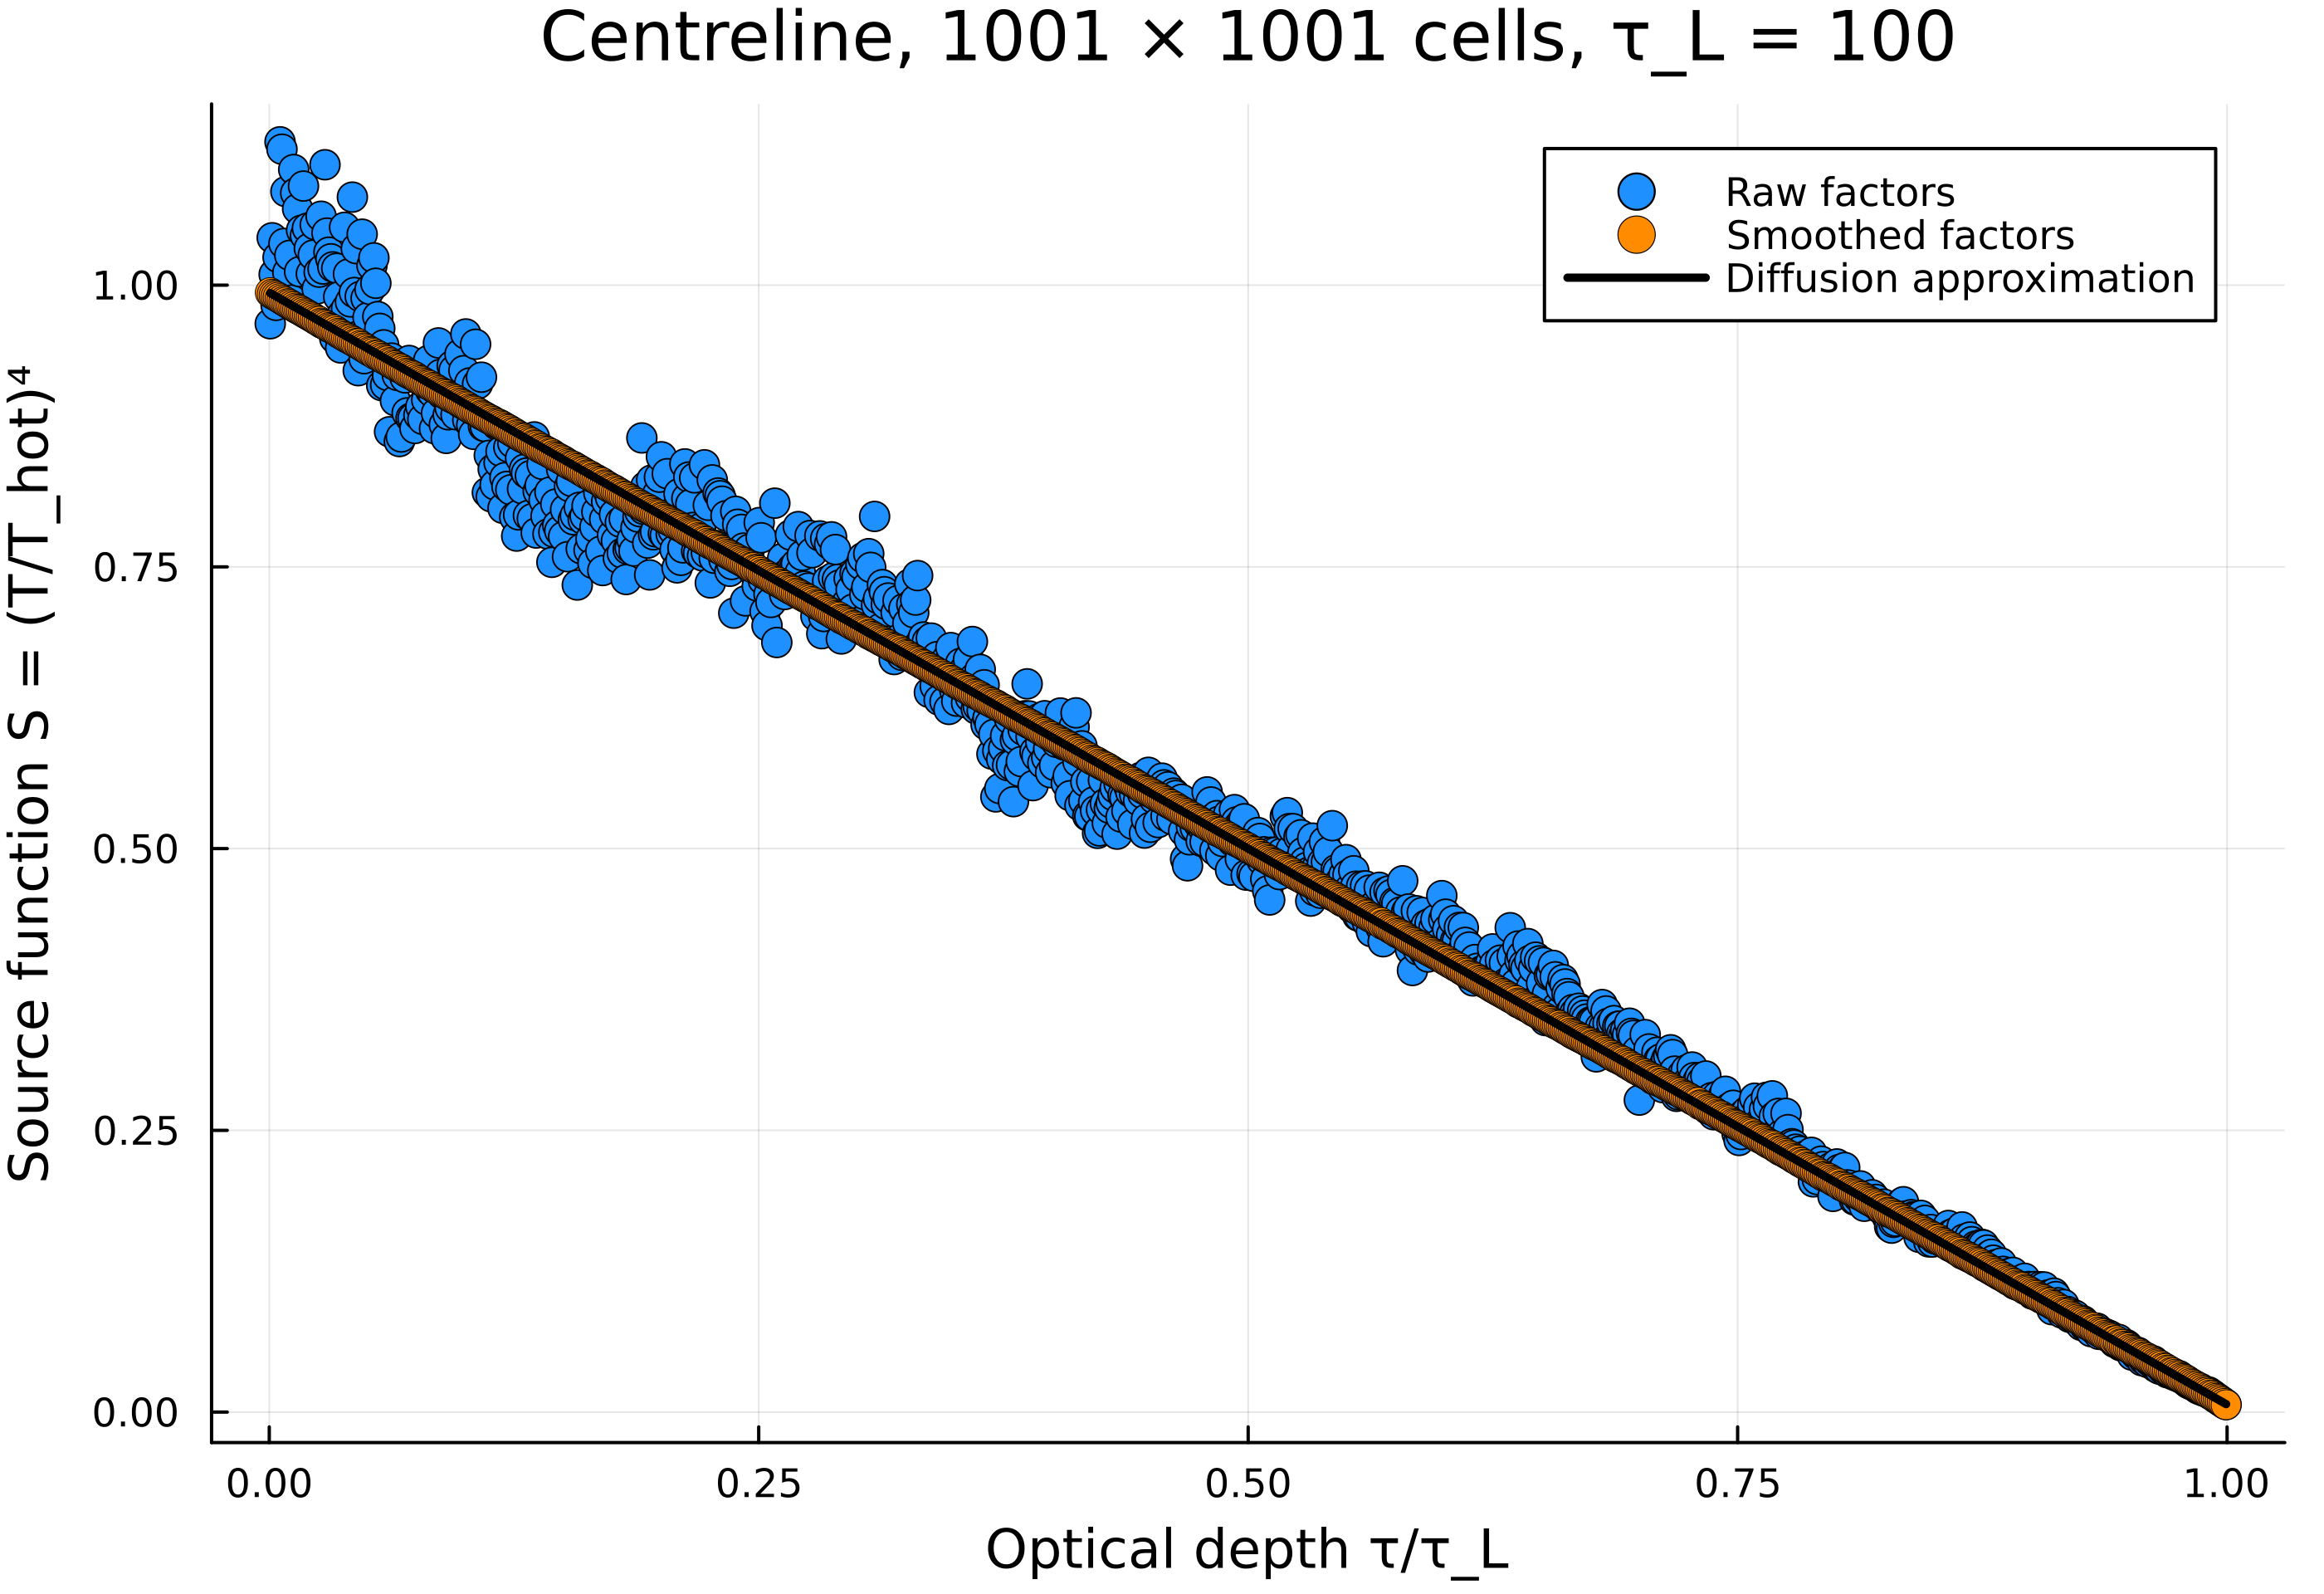

In [5]:
# Emissive power in the diffusion approximation between two parallel grey walls:
# z is the distance from wall 1, β the extinction coefficient, D the distance between the walls
function diffusion_emissive_power(z, β, D, ε_w1, ε_w2, E_bw1, E_bw2)
    q_z  = (E_bw1 - E_bw2) / (3β * D / 4 + 1 / ε_w1 + 1 / ε_w2 - 1)   # net radiative flux between the walls
    E_b1 = E_bw1 + q_z * (1 / 2 - 1 / ε_w1)                          # emissive power just inside wall 1
    return E_b1 - (3β * z / 4) * q_z                                  # falling linearly across the medium
end

σ_SB  = 5.670374419e-8                                                # Stefan–Boltzmann constant, W m⁻² K⁻⁴
E_hot = σ_SB * 1000.0^4                                               # emissive power of the hot wall
z     = ((1:Nlarge) .- 0.5) ./ Nlarge                                 # cell centres: distance from the hot wall, m
S_ref = diffusion_emissive_power.(z, 100.0, 1.0, 1.0, 1.0, E_hot, 0.0) ./ E_hot   # the reference, as S

rms_raw    = sqrt(sum(abs2, S_raw .- S_ref) / Nlarge)                 # rms deviation, raw factors
rms_smooth = sqrt(sum(abs2, S_smooth .- S_ref) / Nlarge)              # rms deviation, smoothed factors
println("rms deviation from diffusion: raw = ", round(rms_raw; sigdigits = 3),
        ", smoothed = ", round(rms_smooth; sigdigits = 3),
        ", reduction = ", round(100 * (1 - rms_smooth / rms_raw); digits = 1), " %")
println("time: build ", round(t_build; digits = 1), " s, trace ", round(t_trace; digits = 1),
        " s, smooth ", round(t_smooth; digits = 1), " s, solve ", round(t_solve; digits = 1),
        " s (raw solve ", round(t_solve_raw; digits = 1), " s), on ", Threads.nthreads(), " threads")

using Plots

p = Plots.scatter(z, S_raw; markersize = 5.0, markerstrokewidth = 0.5,        # 1001 points merge into a band
        color = :dodgerblue, label = "Raw factors", dpi = 400)
Plots.scatter!(p, z, S_smooth; markersize = 5.0, markerstrokewidth = 0.25,
        color = :darkorange, label = "Smoothed factors")
Plots.plot!(p, z, S_ref; color = :black, linewidth = 2.5, label = "Diffusion approximation")
Plots.plot!(p; xlabel = "Optical depth τ/τ_L", ylabel = "Source function S = (T/T_hot)⁴",
        title = "Centreline, 1001 × 1001 cells, τ_L = 100", legend = :topright, size = (700, 480))
display(p)